# XGBoost Model Evaluation and Analysis

/tmp/ipython-input-570173110.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='fuel-name', y='value', data=avg_co2_by_fuel, palette='plasma')


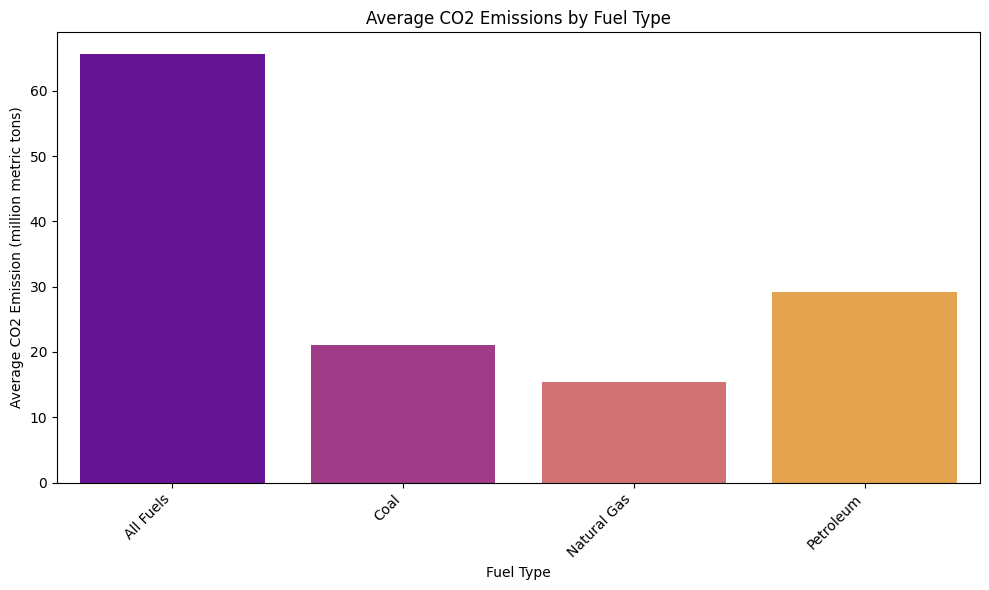

In [13]:
avg_co2_by_fuel = df.groupby('fuel-name')['value'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(x='fuel-name', y='value', data=avg_co2_by_fuel, palette='plasma')
plt.title('Average CO2 Emissions by Fuel Type')
plt.xlabel('Fuel Type')
plt.ylabel('Average CO2 Emission (million metric tons)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Reasoning**:
To address the `FutureWarning` from Seaborn regarding the `palette` argument, I will update the `sns.barplot` call by explicitly setting `hue='fuel-name'` and `legend=False`, as recommended by the warning, to ensure compatibility with future versions and maintain the desired visualization.



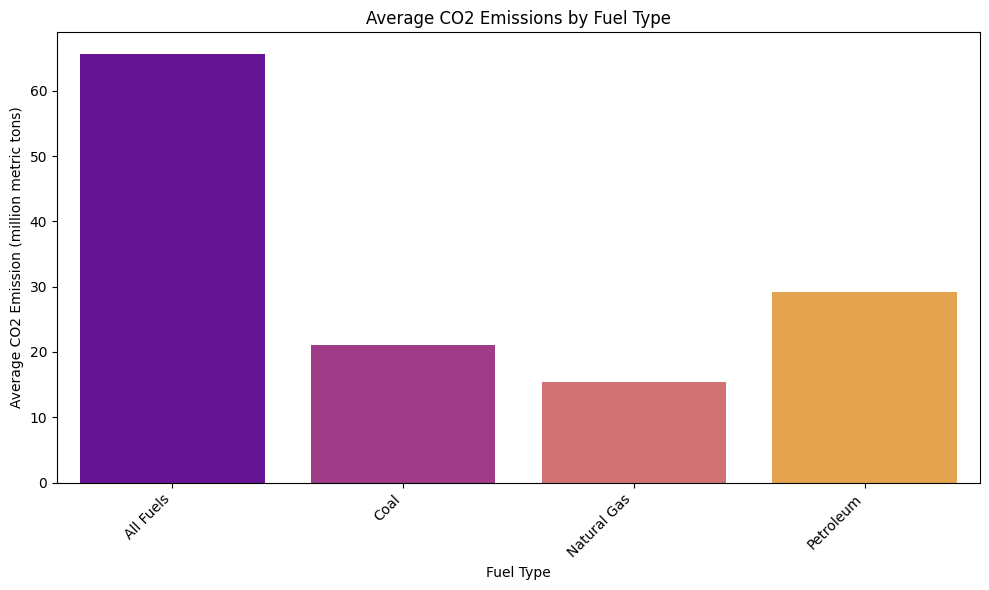

In [14]:
avg_co2_by_fuel = df.groupby('fuel-name')['value'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(x='fuel-name', y='value', data=avg_co2_by_fuel, palette='plasma', hue='fuel-name', legend=False)
plt.title('Average CO2 Emissions by Fuel Type')
plt.xlabel('Fuel Type')
plt.ylabel('Average CO2 Emission (million metric tons)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Summarize Data Characteristics and Cons

### Subtask:
Provide a comprehensive summary of the dataset's characteristics, including a detailed report on the identified 'cons' such as missing values, inconsistencies, or unusual distributions, which will inform our approach to machine learning.


In [23]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

print("Libraries for Random Forest Regressor and evaluation metrics imported successfully.")

Libraries for Random Forest Regressor and evaluation metrics imported successfully.


In [24]:
# Initialize the Random Forest Regressor model
# Using a small number of estimators for quicker demonstration; tune this for better performance
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

# Train the model
print("Training Random Forest Regressor model...")
rf_model.fit(X_train, y_train)
print("Model training complete.")

Training Random Forest Regressor model...
Model training complete.


In [25]:
# Make predictions on the test set
y_pred_rf = rf_model.predict(X_test)
print("Predictions made on the test set.")

Predictions made on the test set.


In [30]:
import joblib

# Load the trained Random Forest Regressor model
loaded_rf_model = joblib.load('/content/random_forest_regressor_model.joblib')

print("Random Forest Regressor model loaded successfully.")

Random Forest Regressor model loaded successfully.


In [31]:
# Make predictions on a portion of the X_test set using the loaded model
# We'll take a small sample for demonstration purposes
sample_X_test = X_test.head(5)
sample_predictions = loaded_rf_model.predict(sample_X_test)

print("Sample predictions using the loaded model:")
for i, pred in enumerate(sample_predictions):
    print(f"Sample {i+1} Predicted Log-Transformed Value: {pred:.4f}")

# Optionally, also show the original (inverse transformed) predictions
sample_predictions_original = np.expm1(sample_predictions)
print("\nSample predictions (Original Scale) using the loaded model:")
for i, pred in enumerate(sample_predictions_original):
    print(f"Sample {i+1} Predicted Original Value: {pred:.4f}")

# And compare with actual values if desired (from y_test)
sample_y_test = y_test.head(5)
sample_y_test_original = np.expm1(sample_y_test)
print("\nCorresponding Actual Log-Transformed Values:")
for i, actual in enumerate(sample_y_test):
    print(f"Sample {i+1} Actual Log-Transformed Value: {actual:.4f}")
print("\nCorresponding Actual Original Values:")
for i, actual in enumerate(sample_y_test_original):
    print(f"Sample {i+1} Actual Original Value: {actual:.4f}")

Sample predictions using the loaded model:
Sample 1 Predicted Log-Transformed Value: 0.3632
Sample 2 Predicted Log-Transformed Value: 4.4774
Sample 3 Predicted Log-Transformed Value: 3.0138
Sample 4 Predicted Log-Transformed Value: 2.4930
Sample 5 Predicted Log-Transformed Value: 1.9265

Sample predictions (Original Scale) using the loaded model:
Sample 1 Predicted Original Value: 0.4379
Sample 2 Predicted Original Value: 87.0047
Sample 3 Predicted Original Value: 19.3648
Sample 4 Predicted Original Value: 11.0971
Sample 5 Predicted Original Value: 5.8654

Corresponding Actual Log-Transformed Values:
Sample 1 Actual Log-Transformed Value: 0.4151
Sample 2 Actual Log-Transformed Value: 4.5041
Sample 3 Actual Log-Transformed Value: 2.9496
Sample 4 Actual Log-Transformed Value: 2.4560
Sample 5 Actual Log-Transformed Value: 1.8944

Corresponding Actual Original Values:
Sample 1 Actual Original Value: 0.5144
Sample 2 Actual Original Value: 89.3846
Sample 3 Actual Original Value: 18.0988
Samp

In [22]:
X_train.to_csv('/content/X_train.csv', index=False)
X_test.to_csv('/content/X_test.csv', index=False)
y_train.to_csv('/content/y_train.csv', index=False, header=['value_log_transformed'])
y_test.to_csv('/content/y_test.csv', index=False, header=['value_log_transformed'])

print("X_train, X_test, y_train, and y_test have been saved to /content/ as CSV files.")

X_train, X_test, y_train, and y_test have been saved to /content/ as CSV files.


### What will the Machine Learning Model do?

Based on the exploratory data analysis and feature engineering we've performed, the machine learning model will be developed to **predict CO2 emission values (`value_log_transformed`)**.

Specifically, it will:

*   **Learn from historical data**: The model will be trained on the `X_train` dataset (which includes engineered features like lagged CO2 values, rolling means, and one-hot encoded sector/fuel types) and `y_train` (the log-transformed CO2 emission values).
*   **Identify patterns**: It will try to uncover complex relationships between the input features (e.g., year, sector, fuel type, historical emissions) and the CO2 emission values.
*   **Forecast future emissions**: Once trained, the model can then be used to predict `value_log_transformed` for unseen data (e.g., future periods or new combinations of sectors/fuel types), using `X_test` for evaluation.

This is a **regression problem**, as we are trying to predict a continuous numerical value (CO2 emissions). The goal is to build a model that can accurately estimate CO2 emissions, which could be valuable for environmental policy-making, impact assessment, or resource planning.

Possible machine learning models for this task include:
*   **Linear Regression**: A simple baseline model.
*   **Tree-based models**: Such as Random Forest Regressor or Gradient Boosting Regressor (e.g., XGBoost, LightGBM), which are generally robust to outliers and can capture non-linear relationships.
*   **Time Series Models**: Given the temporal features we engineered, more advanced time series models like ARIMA, SARIMA, or even neural networks (e.g., LSTMs) could be considered if the focus is on more sophisticated time-dependent forecasting.

## Final Task

### Subtask:
Conclude the data analysis phase by summarizing key findings about the data and its 'cons', setting the stage for subsequent machine learning model development based on these insights.


## Summary:

### Data Analysis Key Findings

*   The dataset contains 66,144 rows and 9 columns, with no missing values in any of the columns.
*   The `period` column, representing the year, spans from 1970 to 2022.
*   The `value` column, representing CO2 emission values, exhibits a heavily right-skewed distribution with a range from 0 to 5990.39 million metric tons of CO2. Descriptive statistics and visualizations (histogram, box plot) clearly indicate the presence of significant outliers, particularly at the higher end of emission values.
*   All categorical columns (`sectorId`, `sector-name`, `fuelId`, `fuel-name`, `stateId`, `state-name`, `value-units`) are consistent and well-defined, with no apparent inconsistencies or data entry errors. The `value-units` column is uniformly "million metric tons of CO2".
*   Visualizations reveal that average CO2 emissions show fluctuations with an overall increasing trend over time.
*   There are significant differences in average CO2 emissions across various sectors, with 'Electric Power' and 'Transportation' being notable contributors, and also across different fuel types, where 'Petroleum', 'Coal', and 'Natural Gas' show distinct emission profiles.

### Insights or Next Steps

*   The primary challenge for machine learning model development will be addressing the heavily right-skewed distribution and significant outliers in the `value` column. Robust outlier detection, handling techniques (e.g., Winsorization or clipping), or data transformations (e.g., log transformation) should be applied to normalize the distribution and prevent models from being overly sensitive to extreme values.
*   The clear trends and differences observed across `period`, `sector-name`, and `fuel-name` suggest these features are highly predictive. Subsequent steps should include effective feature engineering, such as creating time-series features (e.g., lagged values or moving averages) from `period` and appropriate encoding (e.g., one-hot or label encoding) for the categorical variables.


## Analyze and Handle Outliers in 'value' Column

### Subtask:
Examine the 'value' column more deeply to understand the nature of its skewed distribution and outliers. Implement appropriate techniques such as log transformation or Winsorization to normalize the distribution and mitigate the impact of outliers, ensuring the data is suitable for machine learning models.


**Reasoning**:
To address the heavy right-skewness and presence of zero values in the 'value' column, I will apply a log transformation using `np.log1p` to create a new column, `value_log_transformed`, and import `numpy` for this operation.



**Reasoning**:
Now that the log transformation has been applied, I will visualize the distribution of the new 'value_log_transformed' column using a histogram to assess the effectiveness of the transformation.



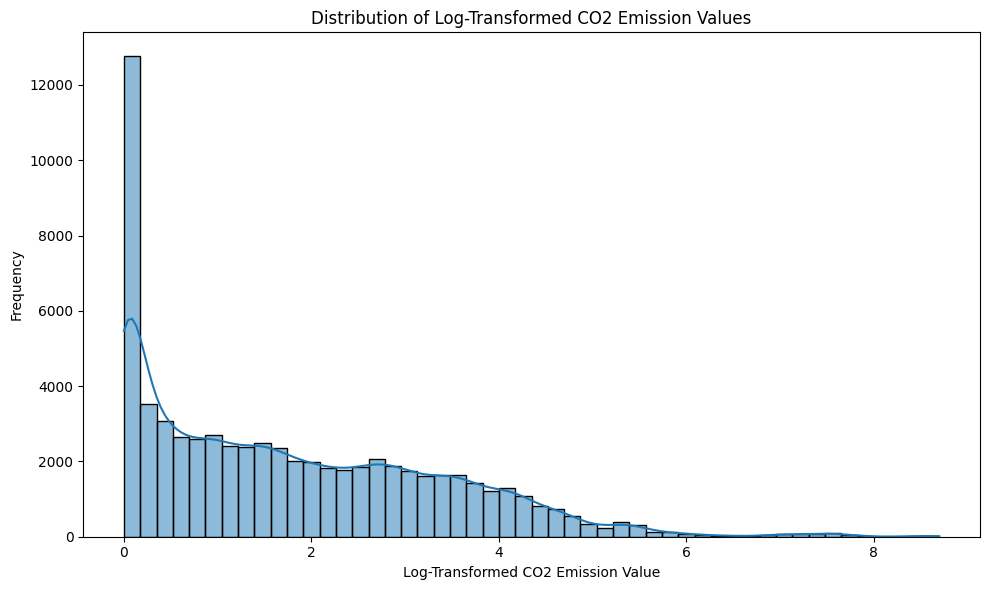

In [16]:
plt.figure(figsize=(10, 6))
sns.histplot(df['value_log_transformed'], bins=50, kde=True)
plt.title('Distribution of Log-Transformed CO2 Emission Values')
plt.xlabel('Log-Transformed CO2 Emission Value')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

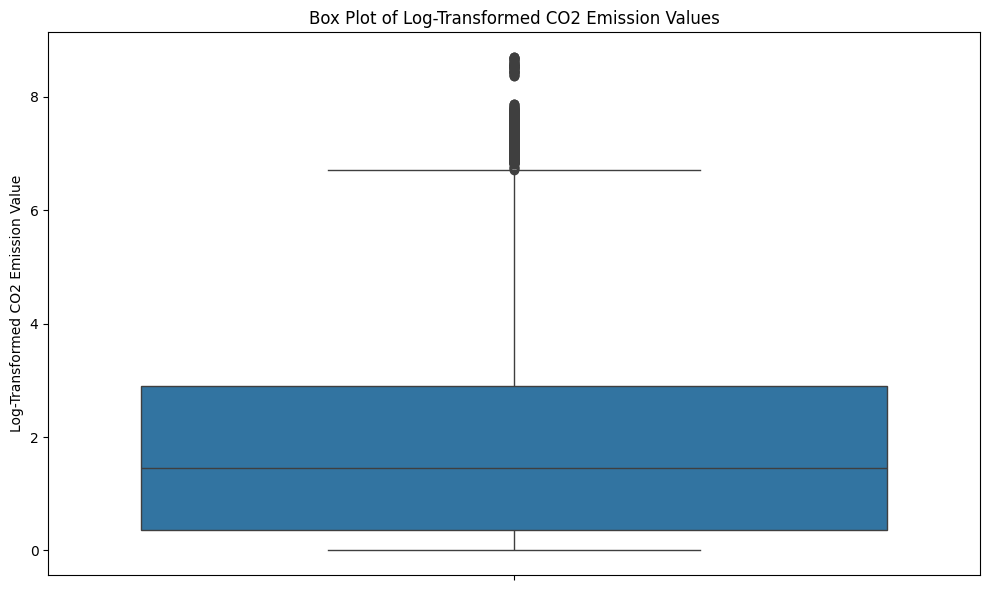

In [17]:
plt.figure(figsize=(10, 6))
sns.boxplot(y=df['value_log_transformed'])
plt.title('Box Plot of Log-Transformed CO2 Emission Values')
plt.ylabel('Log-Transformed CO2 Emission Value')
plt.tight_layout()
plt.show()

## Feature Engineering for Time-Series Data

### Subtask:
Create new features from the 'period' column, such as lagged values or moving averages, to capture temporal patterns that can be beneficial for time-series-aware machine learning models. This will leverage the observed trends over time.


In [18]:
df['date'] = pd.to_datetime(df['period'], format='%Y')
df = df.sort_values(by=['state-name', 'sector-name', 'fuel-name', 'date'])